# Enedis Analytics : notebook de synthese

Ce notebook reproduit les trois taches du projet en utilisant les memes modules Python que
l'application Streamlit (dossiers `utils/` et `models/`). Le but est de suivre le pipeline
de bout en bout, des donnees brutes jusqu'aux resultats.

Donnees : open data Enedis RES2-6-9 kVA, 500 compteurs residentiels, pas de 30 minutes
(48 points par jour). Les valeurs source sont en Wh par demi-heure ; le parser les convertit
en kW (division par 500).

RP = residence principale, RS = residence secondaire.

| Section | Contenu | Module |
|---|---|---|
| 1. Donnees | Chargement et exploration | `utils/parser.py` |
| 2. Descripteurs | 26 features par compteur | `utils/features.py` |
| 3. Classification RS/RP | Stacking HistGBT + RF + LogReg | `models/classifier.py` |
| 4. Prevision J+1 | Ridge, LightGBM, NLinear, reference | `models/forecaster.py` |
| 5. Generation | Courbes synthetiques conditionnelles | `models/generator.py` |

Les labels RS/RP sont fournis dans `RES2-6-9-labels.csv` (issus d'un clustering realise en
amont) et servent ici de verite terrain.

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

PROJECT_DIR = Path(os.path.abspath("")).resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from config import PAL, STEPS_PER_DAY, FCST_HORIZON_H
from utils.parser import parse_timeseries, parse_labels
from utils.features import extract_features
from utils.metrics import compute_metrics
from models.classifier import EnergyClassifier
from models.forecaster import RidgeForecaster, LGBMForecasterV2, NLinearGlobalForecaster
from models.generator import CurveGenerator

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
SEED = 42
np.random.seed(SEED)
GRAY = PAL.MULTI       # niveaux de gris pour l'UI
ACC = PAL.ACCENT       # couleurs vives reservees aux traces
print("Projet :", PROJECT_DIR)

## 1. Chargement et exploration des donnees

Le CSV Enedis a trois colonnes : `id`, `horodate`, `valeur`. Le parser detecte le separateur,
convertit la valeur en kW et renvoie un DataFrame `[meter_id, ts, kw]`. L'energie journaliere
d'un compteur vaut `somme(kW) * 0.5`.

In [2]:
TS_PATH = PROJECT_DIR / "RES2-6-9.csv"
LBL_PATH = PROJECT_DIR / "RES2-6-9-labels.csv"

df = parse_timeseries(TS_PATH, max_meters=None)
lbls = parse_labels(LBL_PATH)

n_rp = sum(v == 0 for v in lbls.values())
n_rs = sum(v == 1 for v in lbls.values())
print(f"Lignes      : {len(df):,}")
print(f"Compteurs   : {df['meter_id'].nunique()}")
print(f"Periode     : {df['ts'].min().date()} a {df['ts'].max().date()}")
print(f"Memoire     : {df.memory_usage(deep=True).sum() / 1e6:.0f} Mo")
print(f"Labels      : {n_rp} RP, {n_rs} RS")
df.head()

Lignes      : 8,736,000
Compteurs   : 500
Periode     : 2023-10-31 a 2024-10-29
Memoire     : 122 Mo
Labels      : 428 RP, 72 RS


,meter_id,ts,kw
0,100542420872,2023-10-31 23:00:00+00:00,1.9084
1,100542420872,2023-10-31 23:30:00+00:00,1.0458
2,100542420872,2023-11-01 00:00:00+00:00,1.6970
3,100542420872,2023-11-01 00:30:00+00:00,0.6374
4,100542420872,2023-11-01 01:00:00+00:00,0.8178


### Profils moyens par type

Le profil moyen sur 48 creneaux montre la difference de forme entre les deux types : la RP
presente un pic du matin et un pic du soir, la RS une base proche de zero avec un seul pic en
soiree. Cette difference est ce que les descripteurs de la section 2 cherchent a capturer.

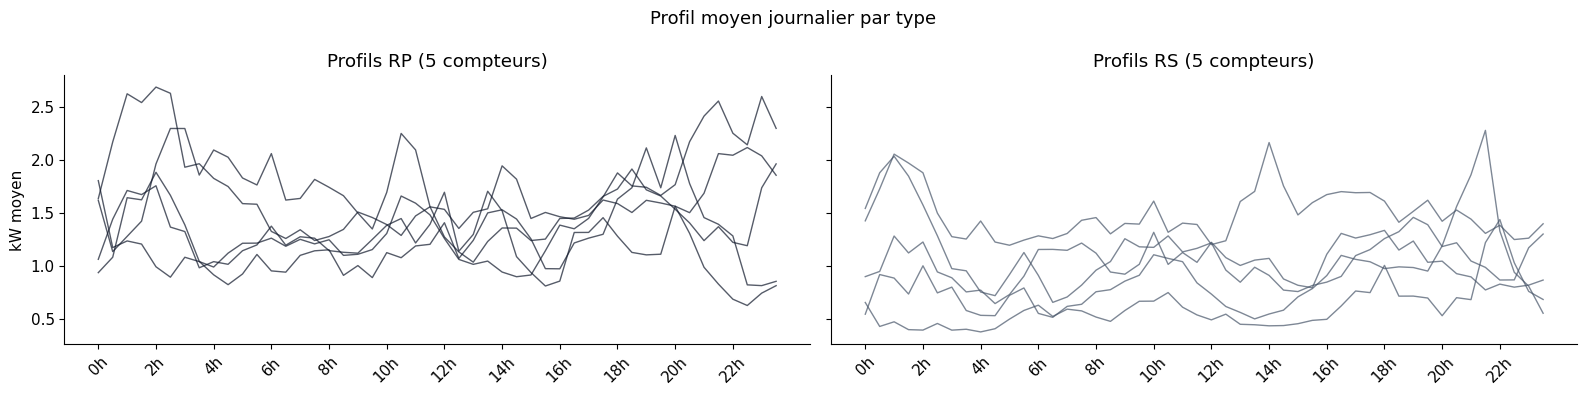

In [3]:
rp_ids = [k for k, v in lbls.items() if v == 0][:5]
rs_ids = [k for k, v in lbls.items() if v == 1][:5]
tick_pos = range(0, STEPS_PER_DAY, 4)
tick_labs = [f"{s // 2}h" for s in tick_pos]


def _profile(mid):
    g = df[df["meter_id"] == mid].copy()
    g["slot"] = g["ts"].dt.hour * 2 + g["ts"].dt.minute // 30
    return g.groupby("slot")["kw"].mean()


fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for mid in rp_ids:
    p = _profile(mid)
    axes[0].plot(p.index, p.values, linewidth=1.0, alpha=0.7, color=GRAY[0])
for mid in rs_ids:
    p = _profile(mid)
    axes[1].plot(p.index, p.values, linewidth=1.0, alpha=0.7, color=GRAY[3])
for ax, title in zip(axes, ["Profils RP (5 compteurs)", "Profils RS (5 compteurs)"]):
    ax.set_xticks(list(tick_pos))
    ax.set_xticklabels(tick_labs, rotation=45)
    ax.set_title(title)
axes[0].set_ylabel("kW moyen")
plt.suptitle("Profil moyen journalier par type", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Descripteurs par compteur

Chaque compteur est resume par 26 features calculees sur tout son historique. Cette agregation
permet de classifier un compteur independamment de la longueur de sa serie.

| Famille | Exemples | Signal recherche |
|---|---|---|
| Presence / absence | `zero_ratio`, `max_gap_days`, `active_days_ratio`, `vacation_weeks` | RS : longues absences |
| Rythme temporel | `ratio_we_wd`, `peak_hour_ratio`, `morning_ratio`, `night_ratio` | RP : pics reguliers |
| Variabilite | `cv_daily_energy`, `cv_weekly`, `weekly_entropy`, `dow_consistency` | RS : semaines irregulieres |
| Saisonnalite | `seasonal_ratio`, `seasonal_presence_gap`, `summer_weekend_boost` | RS : occupation saisonniere |
| Forme spectrale | `fourier_amp_1` a `fourier_amp_6` | structure du profil journalier |

Reference : McLoughlin et al. (2012).

In [4]:
features = extract_features(df)
print(f"Matrice de features : {features.shape[0]} compteurs x {features.shape[1]} features")
features.head()

Matrice de features : 500 compteurs x 26 features


,ratio_we_wd,cv_daily_energy,peak_hour_ratio,night_ratio,morning_ratio,seasonal_ratio,cv_weekly,zero_ratio,autocorr_lag48,max_gap_days,...,fourier_amp_3,fourier_amp_4,fourier_amp_5,fourier_amp_6,weekly_entropy,peak_hour_std,dow_consistency,summer_weekend_boost,night_amplitude,vacation_weeks
meter_id,,,,,,,,,,,,,,,,,,,,,
100542420872,1.053488,0.413582,0.208484,0.256664,0.130048,0.761531,0.373837,0.105769,0.560041,1,...,0.039682,0.131186,0.050994,0.031670,0.999828,1.773756,1.145590,0.776439,8.132010,0.0
101600564162,1.066665,0.484035,0.240854,0.197713,0.082053,1.112476,0.441426,0.000916,0.666276,0,...,0.110623,0.014032,0.034718,0.024993,0.999701,1.652371,1.183867,1.044027,8.946789,0.0
101738209253,1.072584,0.522499,0.164869,0.267072,0.104447,0.312513,0.491048,0.120021,0.608931,3,...,0.093691,0.126666,0.039028,0.052514,0.999656,1.823701,1.380682,0.297511,11.436705,3.0
102535568783,1.061998,0.882430,0.207092,0.216626,0.111635,0.123490,0.878728,0.139423,0.778157,39,...,0.063112,0.090999,0.064594,0.054490,0.999731,2.066230,1.987948,0.138199,7.652701,7.0
103285643131,1.057360,0.726152,0.172312,0.177502,0.151432,0.624571,0.700007,0.055174,0.623431,5,...,0.067431,0.081658,0.037120,0.037123,0.999789,1.810231,1.405248,0.613772,9.804903,1.0


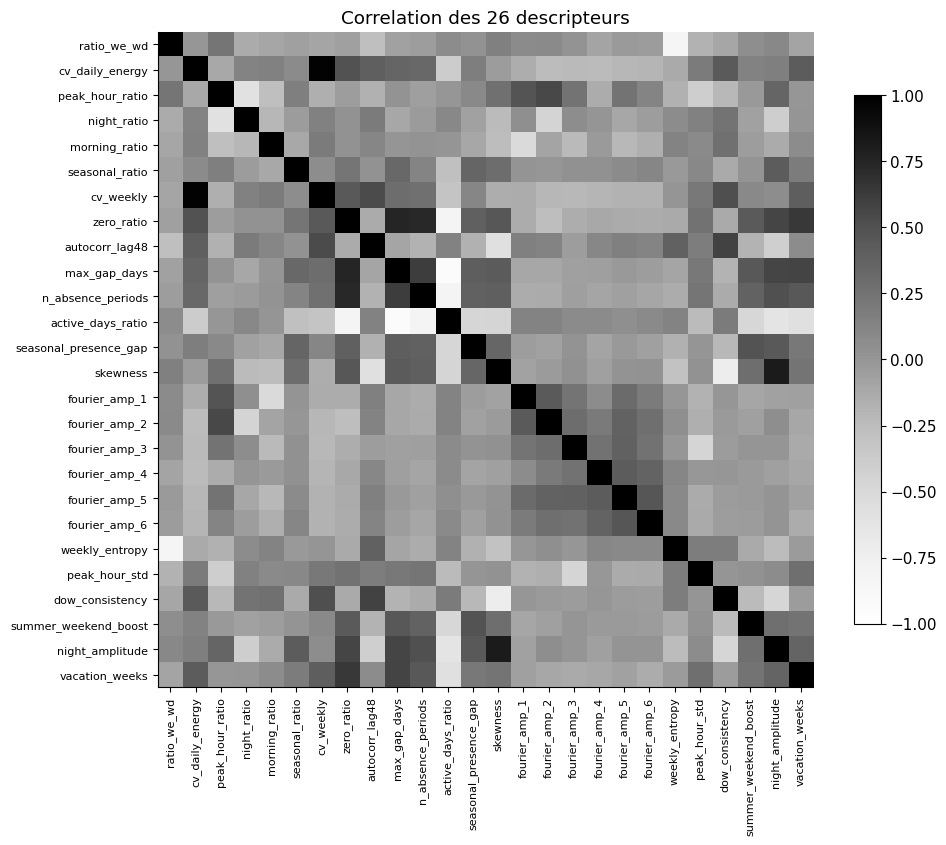

In [5]:
corr = features.corr()
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, cmap="Greys", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_title("Correlation des 26 descripteurs")
plt.tight_layout()
plt.show()

## 3. Classification RS/RP

Le modele `EnergyClassifier` enchaine un `StandardScaler` et un `StackingClassifier` qui
combine trois apprenants (HistGradientBoosting, RandomForest, regression logistique) via un
meta-modele logistique. Le seuil de decision n'est pas fixe a 0.5 : il est appris sur le train
en maximisant le F1 (courbe precision-rappel), puis stocke dans `clf.threshold_`.

Evaluation par validation croisee stratifiee a 5 plis : chaque compteur est predit une fois,
en dehors de son pli d'entrainement (predictions out-of-fold). La matrice de confusion porte
ainsi sur les 500 compteurs sans fuite de donnees.

In [6]:
common = [m for m in features.index if m in lbls]
X = features.loc[common]
y = np.array([lbls[m] for m in common])
print(f"Compteurs labellises : {len(common)}  ({(y == 0).sum()} RP, {(y == 1).sum()} RS)")

Compteurs labellises : 500  (428 RP, 72 RS)


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_pred = np.zeros(len(y), dtype=int)
oof_proba = np.zeros(len(y))

for fold, (tr, te) in enumerate(cv.split(X, y), 1):
    clf = EnergyClassifier().fit(X.iloc[tr], y[tr])
    oof_proba[te] = clf.predict_proba(X.iloc[te])
    oof_pred[te] = clf.predict(X.iloc[te])
    print(f"Pli {fold} : seuil appris = {clf.threshold_:.3f}")

print()
print(classification_report(y, oof_pred, target_names=["RP", "RS"]))

Pli 1 : seuil appris = 0.873


Pli 2 : seuil appris = 0.707


Pli 3 : seuil appris = 0.912


Pli 4 : seuil appris = 0.934


Pli 5 : seuil appris = 0.893

              precision    recall  f1-score   support

          RP       0.96      0.97      0.97       428
          RS       0.83      0.76      0.80        72

    accuracy                           0.94       500
   macro avg       0.90      0.87      0.88       500
weighted avg       0.94      0.94      0.94       500



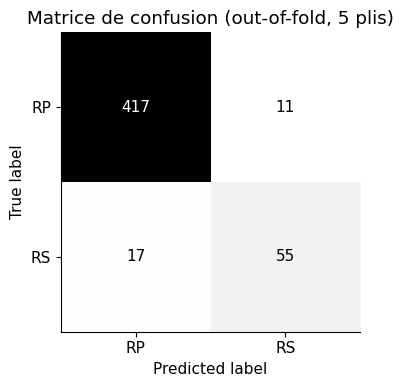

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y, oof_pred), display_labels=["RP", "RS"]
).plot(ax=ax, cmap="Greys", colorbar=False)
ax.set_title("Matrice de confusion (out-of-fold, 5 plis)")
plt.tight_layout()
plt.show()

### Importance des descripteurs

L'importance par permutation mesure la degradation du F1 quand on melange aleatoirement une
feature. Elle est calculee sur le modele entraine sur l'ensemble des compteurs.

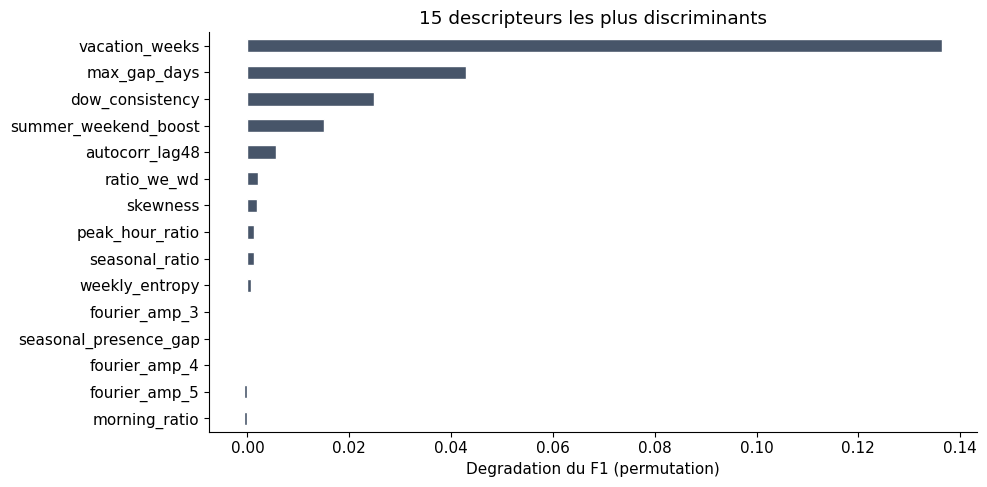

vacation_weeks           0.1365
max_gap_days             0.0430
dow_consistency          0.0248
summer_weekend_boost     0.0150
autocorr_lag48           0.0056
ratio_we_wd              0.0020
skewness                 0.0018
peak_hour_ratio          0.0014
seasonal_ratio           0.0012
weekly_entropy           0.0006
fourier_amp_3            0.0000
seasonal_presence_gap    0.0000
fourier_amp_4            0.0000
fourier_amp_5           -0.0006
morning_ratio           -0.0006
dtype: float64

In [9]:
clf_full = EnergyClassifier().fit(X, y)
imp = clf_full.feature_importances(X, y).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
imp.iloc[::-1].plot.barh(ax=ax, color=GRAY[3], edgecolor="white")
ax.set_xlabel("Degradation du F1 (permutation)")
ax.set_title("15 descripteurs les plus discriminants")
plt.tight_layout()
plt.show()
imp.round(4)

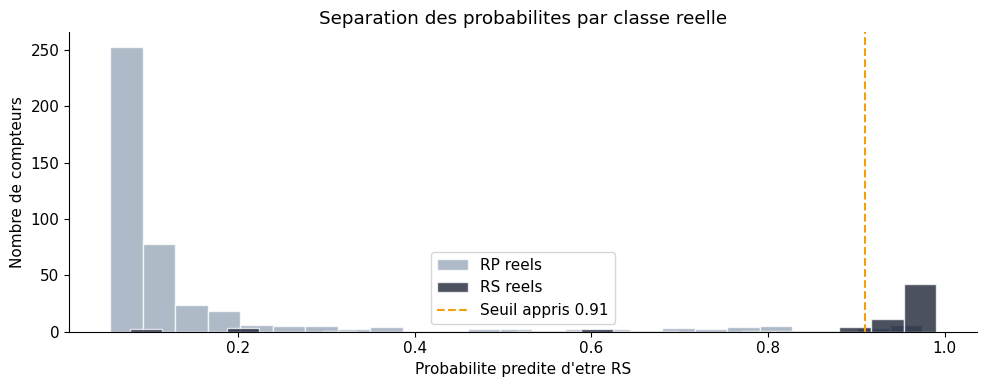

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oof_proba[y == 0], bins=25, alpha=0.75, label="RP reels", color=GRAY[5], edgecolor="white")
ax.hist(oof_proba[y == 1], bins=25, alpha=0.75, label="RS reels", color=GRAY[0], edgecolor="white")
ax.axvline(clf_full.threshold_, color=ACC[1], linestyle="--", linewidth=1.5,
           label=f"Seuil appris {clf_full.threshold_:.2f}")
ax.set_xlabel("Probabilite predite d'etre RS")
ax.set_ylabel("Nombre de compteurs")
ax.set_title("Separation des probabilites par classe reelle")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Prevision J+1

On predit les 48 pas (24 heures) suivants pour un compteur, a partir des 90 derniers jours.
Quatre approches sont comparees, comme dans l'application :

| Modele | Principe |
|---|---|
| Ridge | regression regularisee sur 192 lags + Fourier journalier + calendrier |
| LightGBM | 48 modeles (un par pas), features metier sur le residu vs J-1 |
| NLinear | projection lineaire globale pre-entrainee sur les 500 compteurs |
| Reference | repetition du dernier jour connu, slot par slot |

La reference "demain = hier" est un comparatif exigeant sur des donnees a 30 minutes sans
meteo.

In [11]:
horizon = FCST_HORIZON_H * 2
TRAIN_WINDOW = 90 * STEPS_PER_DAY
min_len = TRAIN_WINDOW + horizon

lengths = df.groupby("meter_id", observed=True).size()
candidates = [m for m in lengths.index if lbls.get(str(m)) == 0 and lengths[m] >= min_len]
meter = candidates[0]

series = df[df["meter_id"] == meter].sort_values("ts")["kw"].values.astype(float)
train = series[-TRAIN_WINDOW - horizon:-horizon]
test = series[-horizon:]
print(f"Compteur : {meter} (RP)")
print(f"Train    : {len(train)} points ({len(train) / STEPS_PER_DAY:.0f} jours)")
print(f"Test     : {len(test)} points ({FCST_HORIZON_H}h)")

Compteur : 100542420872 (RP)
Train    : 4320 points (90 jours)
Test     : 48 points (24h)


In [12]:
def naive_forecast(s, h):
    return np.tile(s[-STEPS_PER_DAY:], h // STEPS_PER_DAY + 1)[:h]


ridge = RidgeForecaster().fit(train)
pred_ridge = ridge.predict(horizon)

lgbm = LGBMForecasterV2().fit(train)
pred_lgbm = lgbm.predict(horizon)

try:
    pred_nlinear = NLinearGlobalForecaster().fit(train).predict(horizon)
except FileNotFoundError:
    pred_nlinear = None

pred_naive = naive_forecast(train, horizon)

results = {
    "Ridge": compute_metrics(test, pred_ridge),
    "LightGBM": compute_metrics(test, pred_lgbm),
    "Reference": compute_metrics(test, pred_naive),
}
if pred_nlinear is not None:
    results["NLinear"] = compute_metrics(test, pred_nlinear)
pd.DataFrame(results).T.round(4)

,MAE,RMSE,MAPE,R2
Ridge,0.5484,0.7564,53.0394,0.6945
LightGBM,0.5106,0.8075,43.0013,0.6518
Reference,0.4468,0.9021,37.5712,0.5655
NLinear,0.5702,0.7943,53.0104,0.6631


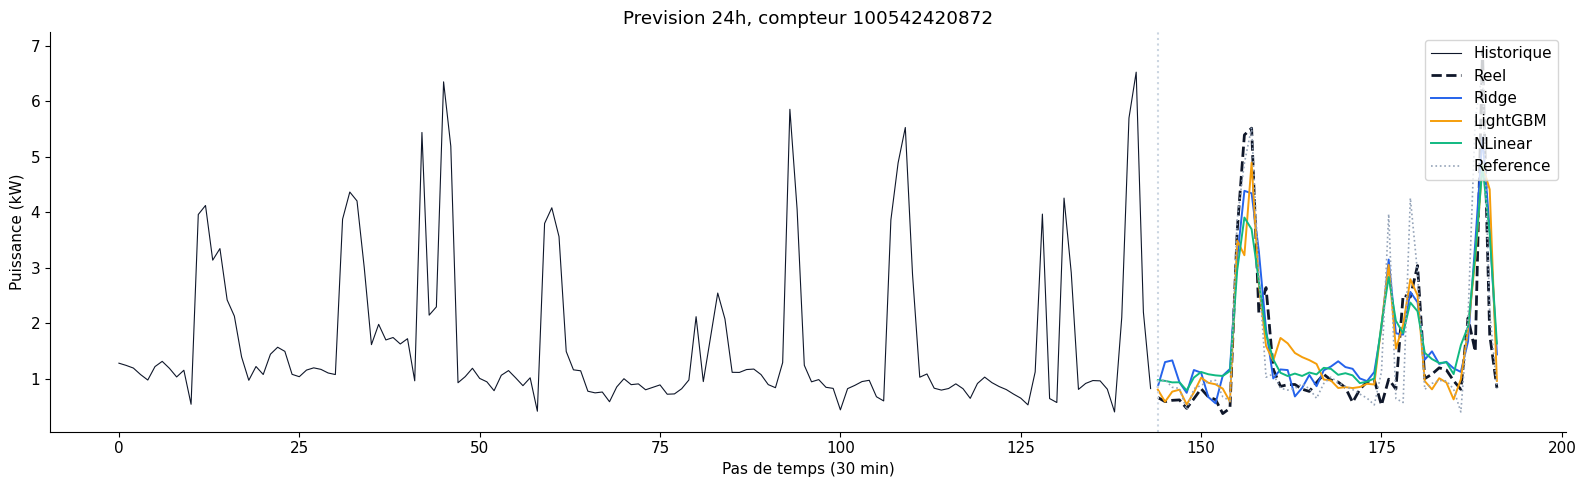

In [13]:
ctx = train[-3 * STEPS_PER_DAY:]
t_ctx = np.arange(len(ctx))
t_pred = np.arange(len(ctx), len(ctx) + horizon)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t_ctx, ctx, color=GRAY[0], linewidth=0.8, label="Historique")
ax.plot(t_pred, test, color=GRAY[0], linewidth=2.0, linestyle="--", label="Reel")
ax.plot(t_pred, pred_ridge, color=ACC[0], linewidth=1.4, label="Ridge")
ax.plot(t_pred, pred_lgbm, color=ACC[1], linewidth=1.4, label="LightGBM")
if pred_nlinear is not None:
    ax.plot(t_pred, pred_nlinear, color=ACC[2], linewidth=1.4, label="NLinear")
ax.plot(t_pred, pred_naive, color=GRAY[5], linewidth=1.2, linestyle=":", label="Reference")
ax.axvline(len(ctx), color=GRAY[6], linestyle=":", linewidth=1.5)
ax.set_xlabel("Pas de temps (30 min)")
ax.set_ylabel("Puissance (kW)")
ax.set_title(f"Prevision 24h, compteur {meter}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 5. Generation de courbes synthetiques

Le generateur est calibre sur les donnees reelles par classe via `fit`. Le mode bootstrap
reechantillonne des journees reelles (conditionnees jour ouvre / week-end), puis ajoute un
facteur journalier de moyenne 1 et un bruit AR(1) de moyenne 0. Ce procede preserve par
construction le pic et l'energie reels.

La qualite est mesuree par `similarity_report` : correlation de Pearson sur la forme du profil
et score discriminatif 1-NN (0.5 = courbes generees indiscernables des reelles, 1.0 =
totalement separables).

In [14]:
gen = CurveGenerator().fit(df, lbls)
curves_rp = gen.generate_bootstrap(n=30, curve_type="RP", n_days=7)
curves_rs = gen.generate_bootstrap(n=30, curve_type="RS", n_days=7)

rep_rp = gen.similarity_report(df, lbls, curves_rp, "RP")
rep_rs = gen.similarity_report(df, lbls, curves_rs, "RS")

for ct, rep in [("RP", rep_rp), ("RS", rep_rs)]:
    print(f"{ct} : Pearson profil = {rep['pearson_profile']:.3f}  |  "
          f"score discriminatif = {rep['discriminative_score']:.3f}  |  "
          f"energie gen/reel = {rep['mean_energy_gen']:.1f}/{rep['mean_energy_real']:.1f} kWh")

RP : Pearson profil = 0.930  |  score discriminatif = 0.510  |  energie gen/reel = 31.5/32.8 kWh
RS : Pearson profil = 0.911  |  score discriminatif = 0.545  |  energie gen/reel = 26.0/25.7 kWh


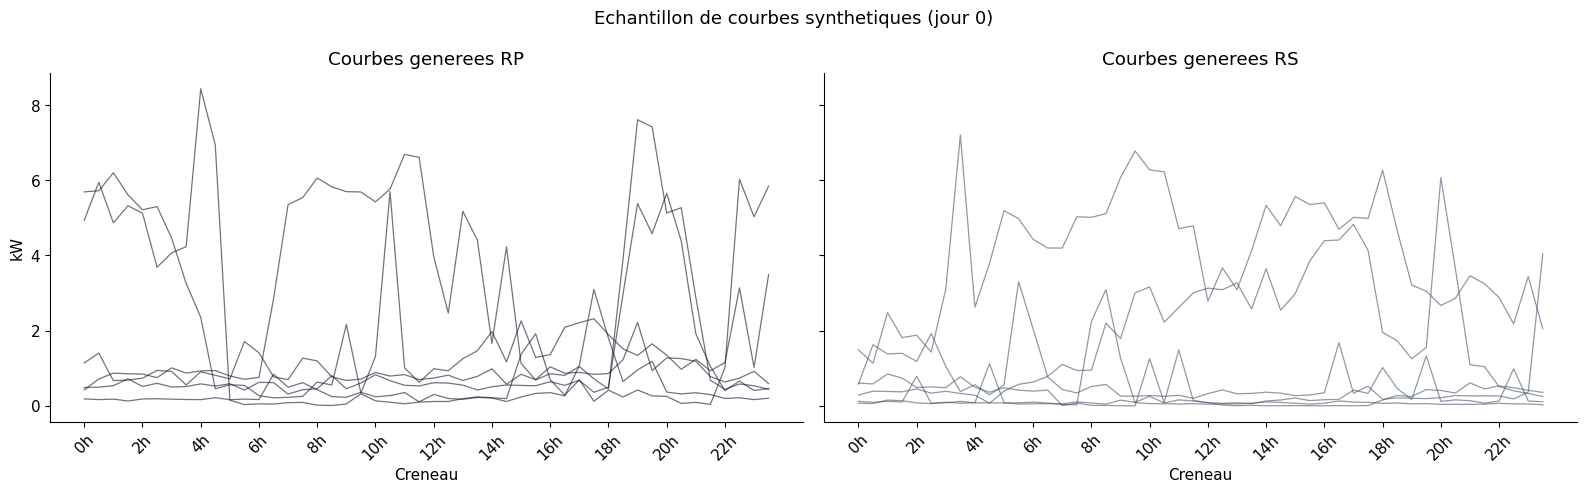

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for cid in range(6):
    d = curves_rp[(curves_rp["curve_id"] == cid) & (curves_rp["day"] == 0)]
    axes[0].plot(d["slot"], d["kw"], linewidth=0.9, alpha=0.6, color=GRAY[0])
for cid in range(6):
    d = curves_rs[(curves_rs["curve_id"] == cid) & (curves_rs["day"] == 0)]
    axes[1].plot(d["slot"], d["kw"], linewidth=0.9, alpha=0.6, color=GRAY[3])
for ax, title in zip(axes, ["Courbes generees RP", "Courbes generees RS"]):
    ax.set_xticks(list(tick_pos))
    ax.set_xticklabels(tick_labs, rotation=45)
    ax.set_xlabel("Creneau")
    ax.set_title(title)
axes[0].set_ylabel("kW")
plt.suptitle("Echantillon de courbes synthetiques (jour 0)", fontsize=13)
plt.tight_layout()
plt.show()

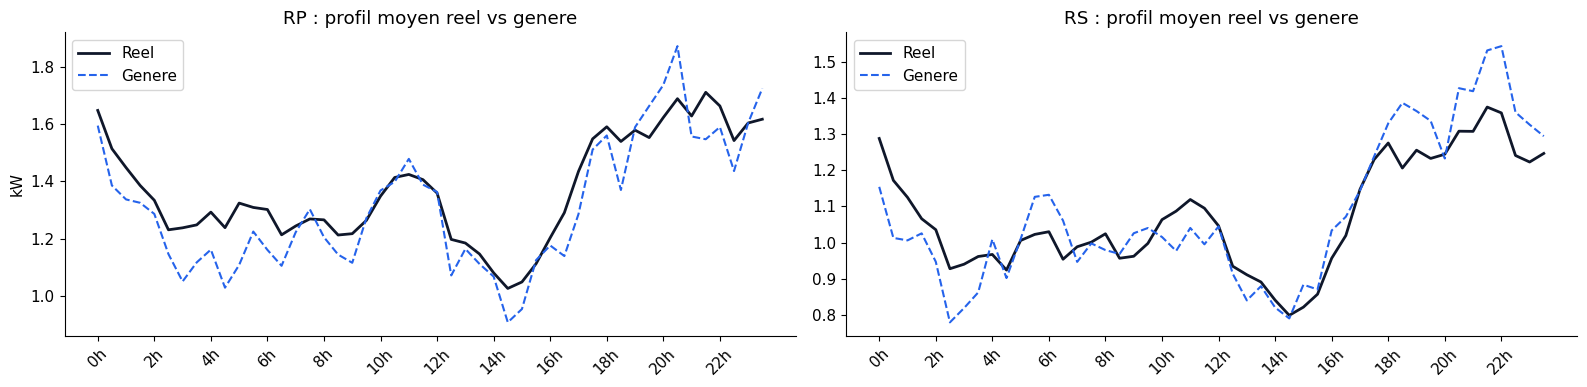

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, ct, rep in zip(axes, ["RP", "RS"], [rep_rp, rep_rs]):
    ax.plot(rep["profile_real"], color=GRAY[0], linewidth=2.0, label="Reel")
    ax.plot(rep["profile_gen"], color=ACC[0], linewidth=1.5, linestyle="--", label="Genere")
    ax.set_xticks(list(tick_pos))
    ax.set_xticklabels(tick_labs, rotation=45)
    ax.set_title(f"{ct} : profil moyen reel vs genere")
    ax.legend()
axes[0].set_ylabel("kW")
plt.tight_layout()
plt.show()

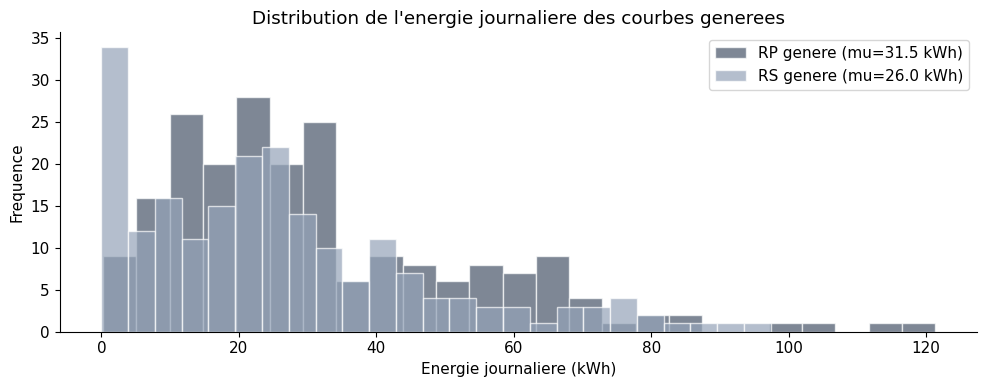

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rep_rp["energy_gen"], bins=25, alpha=0.7, color=GRAY[3], edgecolor="white",
        label=f"RP genere (mu={rep_rp['mean_energy_gen']:.1f} kWh)")
ax.hist(rep_rs["energy_gen"], bins=25, alpha=0.7, color=GRAY[5], edgecolor="white",
        label=f"RS genere (mu={rep_rs['mean_energy_gen']:.1f} kWh)")
ax.set_xlabel("Energie journaliere (kWh)")
ax.set_ylabel("Frequence")
ax.set_title("Distribution de l'energie journaliere des courbes generees")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusion

Classification RS/RP : le stacking avec seuil appris distingue les deux types a partir de
descripteurs comportementaux. Le descripteur le plus discriminant reste le rapport de
consommation week-end sur semaine. La limite tient aux RS occupees toute l'annee, peu
separables des RP sans donnees externes.

Prevision J+1 : Ridge et LightGBM ameliorent la reference "demain = hier", qui demeure un
comparatif difficile sur ce pas de temps. NLinear apporte une projection globale a cout quasi
nul.

Generation : le mode bootstrap reproduit fidelement la forme (Pearson eleve) et l'energie
moyenne des deux classes, le pic et l'energie reels etant preserves par construction.